Results may vary with each run as a seed was not used

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from keras._tf_keras.keras.preprocessing.image import load_img

from keras._tf_keras.keras.applications.xception import Xception
#added preprocessing after looking at prediction values << 0
from keras._tf_keras.keras.applications.xception import preprocess_input
#decode prediction probabilities
from keras._tf_keras.keras.applications.xception import decode_predictions

#transfer learning
from keras._tf_keras.keras.preprocessing.image import ImageDataGenerator
from keras._tf_keras.keras.layers import GlobalAveragePooling2D, Dense
from keras._tf_keras.keras.optimizers import Adam
from keras._tf_keras.keras.losses import CategoricalCrossentropy

#callbacks
from keras._tf_keras.keras.callbacks import ModelCheckpoint

#dropout
from keras._tf_keras.keras.layers import Dropout

#load
from keras._tf_keras.keras.models import load_model

In [35]:
print("GPUs Available: ", tf.config.list_physical_devices('GPU'))

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [36]:
#gpus = tf.config.list_physical_devices("GPU")
#
#tf.config.set_logical_device_configuration(
#    gpus[0],
#    [tf.config.LogicalDeviceConfiguration(memory_limit=4096)]  # Limit to 1GB
#)

In [37]:
#tf.debugging.set_log_device_placement(True)

In [38]:
#with tf.device('/GPU:0'):

In [39]:
img_path = "../data/train/curly/"
img_name = "00cbad1ffe22d900018e5a2e7376daed4.jpg"
full_name = f"{img_path}/{img_name}"

#a neural network expects an image of certain size
img = load_img(full_name, target_size=(299, 299, 3))

In [40]:
#img of size 299x299 => (Height, Width, #Channels) => (299, 299, 3)
print(img)

<PIL.Image.Image image mode=RGB size=299x299 at 0x771C0C5E8370>


In [41]:
x = np.array(img)
x.shape

(299, 299, 3)

In [42]:
x

array([[[ 95,  86,  71],
        [ 97,  88,  73],
        [ 97,  88,  73],
        ...,
        [146, 141, 119],
        [147, 142, 120],
        [148, 143, 121]],

       [[ 95,  86,  71],
        [ 97,  88,  73],
        [ 98,  89,  74],
        ...,
        [146, 141, 119],
        [146, 141, 119],
        [147, 142, 120]],

       [[ 98,  87,  69],
        [100,  89,  71],
        [101,  90,  72],
        ...,
        [148, 143, 121],
        [148, 143, 121],
        [148, 143, 121]],

       ...,

       [[116,  82,  57],
        [118,  84,  59],
        [119,  85,  60],
        ...,
        [226, 225, 220],
        [225, 224, 219],
        [222, 221, 216]],

       [[119,  85,  60],
        [120,  86,  61],
        [120,  86,  61],
        ...,
        [225, 224, 219],
        [222, 221, 216],
        [218, 217, 212]],

       [[120,  86,  61],
        [121,  87,  62],
        [120,  86,  61],
        ...,
        [216, 215, 210],
        [218, 217, 212],
        [222, 221, 216]]

In [43]:
#pre-trained models https://keras.io/api/applications/

In [44]:
#download the model input shape matters it asked for the 3 at the end not 299, 299 as shown in lecture
model = Xception(weights="imagenet", input_shape=(299, 299, 3))

In [45]:
#an array of images each with a structure of (299,299,3)
X = np.array([x])

In [46]:
X.shape

(1, 299, 299, 3)

In [47]:
X = preprocess_input(X)

In [48]:
# x in range [-1, 1]
X[0]

array([[[-0.25490195, -0.32549018, -0.44313723],
        [-0.23921567, -0.3098039 , -0.42745095],
        [-0.23921567, -0.3098039 , -0.42745095],
        ...,
        [ 0.14509809,  0.10588241, -0.06666666],
        [ 0.15294123,  0.11372554, -0.05882353],
        [ 0.16078436,  0.12156868, -0.05098039]],

       [[-0.25490195, -0.32549018, -0.44313723],
        [-0.23921567, -0.3098039 , -0.42745095],
        [-0.23137254, -0.30196077, -0.41960782],
        ...,
        [ 0.14509809,  0.10588241, -0.06666666],
        [ 0.14509809,  0.10588241, -0.06666666],
        [ 0.15294123,  0.11372554, -0.05882353]],

       [[-0.23137254, -0.31764704, -0.4588235 ],
        [-0.21568626, -0.30196077, -0.44313723],
        [-0.20784312, -0.29411763, -0.4352941 ],
        ...,
        [ 0.16078436,  0.12156868, -0.05098039],
        [ 0.16078436,  0.12156868, -0.05098039],
        [ 0.16078436,  0.12156868, -0.05098039]],

       ...,

       [[-0.09019607, -0.35686272, -0.5529412 ],
        [-0

In [49]:
#model expects a batch of images
#if prediction array has values << 0 data requires preprocessing
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [50]:
# an image with a thousand classes, each value is a probability of the image belonging to a class
pred.shape

(1, 1000)

In [51]:
decode_predictions(pred)

[[('n04584207', 'wig', np.float32(0.3383516)),
  ('n03770439', 'miniskirt', np.float32(0.04281734)),
  ('n03710637', 'maillot', np.float32(0.020922674)),
  ('n03595614', 'jersey', np.float32(0.02015887)),
  ('n03476991', 'hair_spray', np.float32(0.020016264))]]

## CNN

#### Convolutional layer
Apply a filter to the original image looking for shapes in the image, if found it assigns a higher value if not assigns zero \
With each pass the next filter uses the output of the previously applied filter \
As filters are applied their complexity increases they can be combinations of past filters \
Each applied filter outpur is a feature map \
After all filters have been applied the result is a vector representation usually in powers of 2, which captures image features which can be used by cnns



It seems that using geometric shapes regular or irregular is the way to go as most objects
in nature follow geometric patterns

#### Dense Layers

Vector representation is used as in the linear regression the sum of the coefficients and the weight of each coefficient and to determine a probability the result is passed to a sigmoid function which yields the probability

For multiple categories the sigmoid for multiple classes is called soft max, which is a multiple logistic regressions

It is called dense layer as each element of the input (vector representation) is connected with each element of the output (classes)

## Transfer Leaning

#### 

Keep already trained convolutional layers and vector representation

Train new Dense Layers

In [52]:
# 150x150 was chosen to train faster
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
# (32, 150, 150, 3)
train_ds = train_gen.flow_from_directory("../data/train/", target_size=(150, 150), batch_size=32)

Found 800 images belonging to 2 classes.


In [53]:
train_ds.class_indices

{'curly': 0, 'straight': 1}

In [54]:
# features, labels
X, y = next(train_ds)

In [55]:
X.shape

(32, 150, 150, 3)

In [56]:
y

array([[0., 1.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.],
       [0., 1.],
       [1., 0.],
       [1., 0.]], dtype=float32)

In [57]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_ds = val_gen.flow_from_directory(
    "../data/test",
    target_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 201 images belonging to 2 classes.


In [58]:
#train a custom base model
#inclue top false refers to only include convolutional layers, not dense layers
base_model = Xception(weights="imagenet", include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False

In [59]:
inputs = keras.Input(shape=(150, 150, 3))

outputs = base_model(inputs)

model = keras.Model(inputs, outputs)

In [60]:
# inputs is X and outputs is the prediction
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [61]:
# a batch of 32 imgs each of size 5x5x2048 like a bread where each slice is of 5x5 wxh and depth 2048
# pooling is going to convert each slice to a scalar with the avg of the elements inside of the 5x5 slice
# to go from 3D do 1D
preds.shape

(32, 5, 5, 2048)

## Pooling

In [62]:
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs)

outputs = GlobalAveragePooling2D()(base)

model = keras.Model(inputs, outputs)

In [63]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [64]:
preds.shape

(32, 2048)

## Dense Layers (turn vectors into predictions)

In [65]:
# (32, 2048) => (32, 2)
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = GlobalAveragePooling2D()(base)

outputs = Dense(2)(vectors)

model = keras.Model(inputs, outputs)

In [66]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [67]:
preds.shape

(32, 2)

## Optimizer (changing the weights so the model learns something)

In [68]:
learning_rate = 0.01
optimizer = Adam(learning_rate=learning_rate)

loss = CategoricalCrossentropy(from_logits=True)

In [69]:
model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

In [70]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - accuracy: 0.7167 - loss: 0.6408

2025-11-28 13:15:17.916219: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:15:18.029576: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:15:18.143061: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:15:18.415932: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:15:18.526545: E external/local_xla/xla/stream_

25/25 ━━━━━━━━━━━━━━━━━━━━ 21s 590ms/step - accuracy: 0.8188 - loss: 0.5012 - val_accuracy: 0.9254 - val_loss: 0.2119
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9312 - loss: 0.2050 - val_accuracy: 0.9303 - val_loss: 0.2075
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9563 - loss: 0.1246 - val_accuracy: 0.9204 - val_loss: 0.3171
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9800 - loss: 0.0589 - val_accuracy: 0.9204 - val_loss: 0.2480
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9850 - loss: 0.0548 - val_accuracy: 0.9204 - val_loss: 0.2547
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9825 - loss: 0.0436 - val_accuracy: 0.9254 - val_loss: 0.2661
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9925 - loss: 0.0227 - val_accuracy: 0.9254 - val_loss: 0.2607
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9987 - loss: 0.0109 - val_accuracy: 0.9204 - val

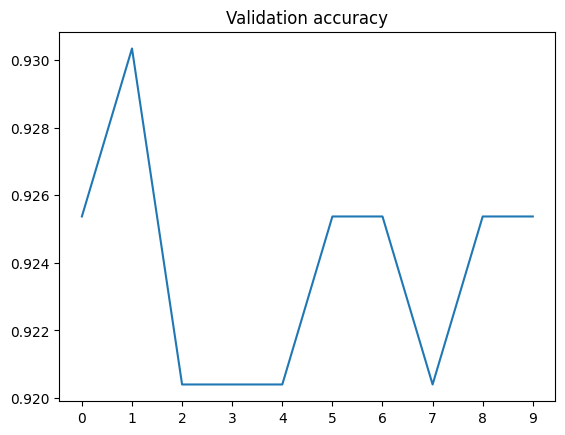

In [71]:
plt.plot(history.history["val_accuracy"])
plt.xticks(np.arange(10))
plt.title("Validation accuracy")
plt.show()

## Adjust Learning Rate

In [72]:
def make_model(learning_rate):
    base_model = Xception(
        weights="imagenet", 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = GlobalAveragePooling2D()(base)
    outputs = Dense(2)(vectors)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=["accuracy"]
    )

    return model

In [73]:
scores = {}
learn_rates = [0.0001, 0.001, 0.01, 0.1]

for lr in learn_rates:
    print(f"Learning rate: {lr}")

    model = make_model(learning_rate=lr)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[lr] = history.history

    print("====")
    print("====")

Learning rate: 0.0001
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 407ms/step - accuracy: 0.5800 - loss: 0.6843 - val_accuracy: 0.5920 - val_loss: 0.6603
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.7563 - loss: 0.5532 - val_accuracy: 0.7363 - val_loss: 0.5571
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.8288 - loss: 0.4702 - val_accuracy: 0.7612 - val_loss: 0.4930
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8475 - loss: 0.4175 - val_accuracy: 0.8109 - val_loss: 0.4459
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8600 - loss: 0.3780 - val_accuracy: 0.8507 - val_loss: 0.4115
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.8775 - loss: 0.3491 - val_accuracy: 0.8756 - val_loss: 0.3850
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 179ms/step - accuracy: 0.8900 - loss: 0.3247 - val_accuracy: 0.9005 - val_loss: 0.3625
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.8950 - loss: 0.

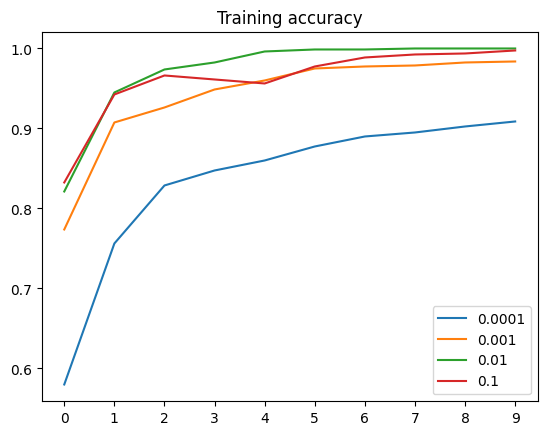

In [74]:
for lr, history in scores.items():
    plt.plot(history["accuracy"], label=lr)

plt.xticks(np.arange(10))
plt.title("Training accuracy")
plt.legend()
plt.show()

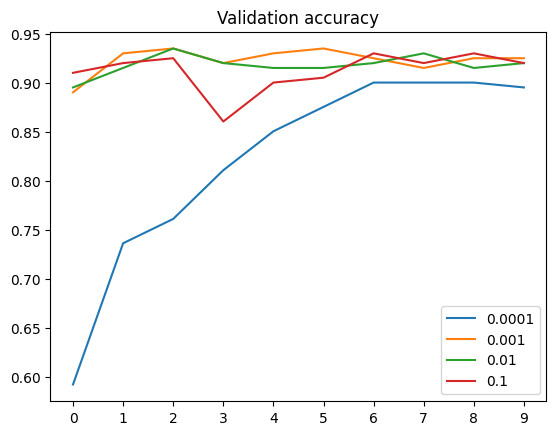

In [75]:
for lr, history in scores.items():
    plt.plot(history["val_accuracy"], label=lr)

plt.xticks(np.arange(10))
plt.title("Validation accuracy")
plt.legend()
plt.show()

In [76]:
del scores[0.0001]

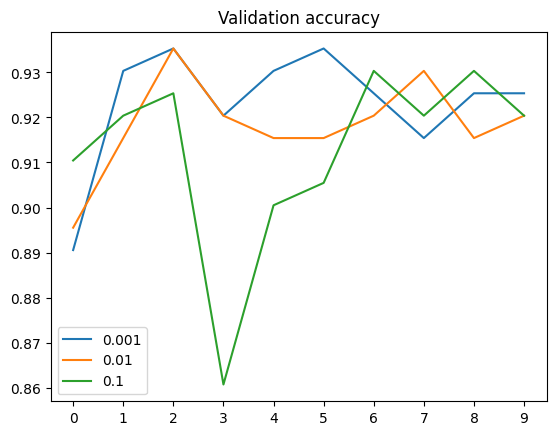

In [77]:
for lr, history in scores.items():
    plt.plot(history["val_accuracy"], label=lr)

plt.xticks(np.arange(10))
plt.title("Validation accuracy")
plt.legend()
plt.show()

In [78]:
selected_lr = 0.001

## Checkpointing

In [79]:
#h5 is format for keras models but is legacy
#model.save_weights("model_v1.weights.h5")

In [80]:
checkpoint = ModelCheckpoint(
    "xception_v1_{epoch:02d}_val{val_accuracy:.3f}.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [81]:
model = make_model(learning_rate=selected_lr)
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint]
)

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 423ms/step - accuracy: 0.7750 - loss: 0.4498 - val_accuracy: 0.8756 - val_loss: 0.2968
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step - accuracy: 0.9162 - loss: 0.2328 - val_accuracy: 0.9104 - val_loss: 0.2317
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9362 - loss: 0.1789 - val_accuracy: 0.8905 - val_loss: 0.2313
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 193ms/step - accuracy: 0.9513 - loss: 0.1462 - val_accuracy: 0.9154 - val_loss: 0.2110
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step - accuracy: 0.9650 - loss: 0.1227 - val_accuracy: 0.9254 - val_loss: 0.2014
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9712 - loss: 0.1071 - val_accuracy: 0.9254 - val_loss: 0.1884
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step - accuracy: 0.9775 - loss: 0.1019 - val_accuracy: 0.9353 - val_loss: 0.1833
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9850 - loss: 0.0835 - val_accuracy: 0

## Add More Layers

#### Layers are used in order to achieve higher performance (if possible)

In [82]:
#copy code from adjusting learning rate to add layers code
#size_inner has to be tuned
def make_model(learning_rate, size_inner=100):
    base_model = Xception(
        weights="imagenet", 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = GlobalAveragePooling2D()(base)
    
    inner_layer = Dense(size_inner, activation="relu")(vectors)

    outputs = Dense(2)(inner_layer)
    #outputs = Dense(2, activation="softmax")(inner_layer)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    #no softmax explicitly used as from_logits is True
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=["accuracy"]
    )

    return model

In [83]:
scores = {}
inner_sizes = [10, 100, 1000]

for sz in inner_sizes:
    print(f"Inner size: {sz}")

    model = make_model(learning_rate=selected_lr, size_inner=sz)
    history = model.fit(train_ds, epochs=10, validation_data=val_ds)
    scores[sz] = history.history

    print("====")
    print("====")

Inner size: 10
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 19s 449ms/step - accuracy: 0.8012 - loss: 0.4228 - val_accuracy: 0.8955 - val_loss: 0.2477
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9300 - loss: 0.1892 - val_accuracy: 0.9055 - val_loss: 0.2062
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9575 - loss: 0.1250 - val_accuracy: 0.9055 - val_loss: 0.1841
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9775 - loss: 0.0878 - val_accuracy: 0.9254 - val_loss: 0.1791
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9850 - loss: 0.0712 - val_accuracy: 0.9154 - val_loss: 0.1886
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.9875 - loss: 0.0549 - val_accuracy: 0.9353 - val_loss: 0.1815
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9912 - loss: 0.0419 - val_accuracy: 0.9303 - val_loss: 0.1760
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.9950 - loss: 0.0328 - 

2025-11-28 13:21:57.192692: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 13:21:59.141157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 68 bytes spill stores, 68 bytes spill loads



25/25 ━━━━━━━━━━━━━━━━━━━━ 20s 432ms/step - accuracy: 0.8238 - loss: 0.3809 - val_accuracy: 0.8905 - val_loss: 0.2585
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.9450 - loss: 0.1497 - val_accuracy: 0.9254 - val_loss: 0.1899
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9737 - loss: 0.0812 - val_accuracy: 0.9353 - val_loss: 0.1910
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.9875 - loss: 0.0510 - val_accuracy: 0.9204 - val_loss: 0.1931
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9912 - loss: 0.0398 - val_accuracy: 0.9204 - val_loss: 0.1976
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.9975 - loss: 0.0255 - val_accuracy: 0.9154 - val_loss: 0.2193
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 1.0000 - loss: 0.0155 - val_accuracy: 0.9204 - val_loss: 0.2072
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 0.9353 - val

2025-11-28 13:22:57.733881: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2025-11-28 13:22:58.663936: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3793', 24 bytes spill stores, 24 bytes spill loads

2025-11-28 13:23:00.550403: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4237', 68 bytes spill stores, 68 bytes spill loads



25/25 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.8400 - loss: 0.4070 - val_accuracy: 0.8756 - val_loss: 0.2975
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 0.9650 - loss: 0.0984 - val_accuracy: 0.9453 - val_loss: 0.1657
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9825 - loss: 0.0543 - val_accuracy: 0.9403 - val_loss: 0.1742
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9912 - loss: 0.0273 - val_accuracy: 0.9303 - val_loss: 0.1837
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 0.9403 - val_loss: 0.1861
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 1.0000 - loss: 0.0059 - val_accuracy: 0.9403 - val_loss: 0.2005
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.9403 - val_loss: 0.2003
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.9403 - val

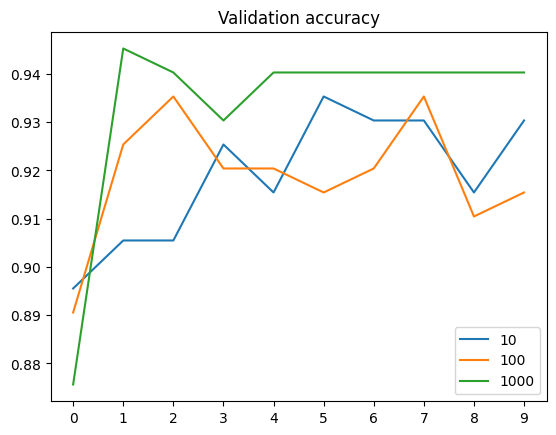

In [84]:
for sz, history in scores.items():
    plt.plot(history["val_accuracy"], label=sz)

plt.xticks(np.arange(10))
plt.title("Validation accuracy")
plt.legend()
plt.show()

In [85]:
sz = 1000

## Dropuot and regularization

#### THe CNN must focus on the shape more than on specific details ob the object

In [86]:
#copy code from adding more layers
#size_inner has been set to 100 so it does not take long
def make_model(learning_rate, size_inner=100, droprate=0.5):
    base_model = Xception(
        weights="imagenet", 
        include_top=False, 
        input_shape=(150, 150, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = GlobalAveragePooling2D()(base)
    
    inner_layer = Dense(size_inner, activation="relu")(vectors)
    drop = Dropout(rate=droprate)(inner_layer)

    outputs = Dense(2)(drop)
    #outputs = Dense(2, activation="softmax")(inner_layer)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    #no softmax explicitly used as from_logits is True
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=["accuracy"]
    )

    return model

In [87]:
scores = {}
drop_rates = [0.0, 0.2, 0.5, 0.8]

for dr in drop_rates:
    print(f"Drop rate: {dr}")

    model = make_model(
        learning_rate=selected_lr,
        size_inner=100,
        droprate=dr
    )

    history = model.fit(train_ds, epochs=30, validation_data=val_ds)
    scores[dr] = history.history

    print("====")
    print("====")

Drop rate: 0.0
Epoch 1/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 18s 417ms/step - accuracy: 0.8338 - loss: 0.3474 - val_accuracy: 0.8806 - val_loss: 0.2664
Epoch 2/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9488 - loss: 0.1312 - val_accuracy: 0.9055 - val_loss: 0.2577
Epoch 3/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 169ms/step - accuracy: 0.9787 - loss: 0.0733 - val_accuracy: 0.9254 - val_loss: 0.1863
Epoch 4/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 172ms/step - accuracy: 0.9837 - loss: 0.0492 - val_accuracy: 0.9204 - val_loss: 0.1730
Epoch 5/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - accuracy: 0.9937 - loss: 0.0325 - val_accuracy: 0.9353 - val_loss: 0.2086
Epoch 6/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.9975 - loss: 0.0197 - val_accuracy: 0.9254 - val_loss: 0.1869
Epoch 7/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 175ms/step - accuracy: 1.0000 - loss: 0.0116 - val_accuracy: 0.9204 - val_loss: 0.1910
Epoch 8/30
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 167ms/step - accuracy: 1.0000 - loss: 0.0084 - 

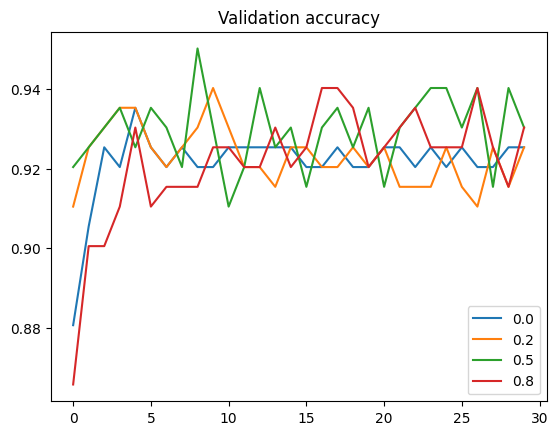

In [88]:
for dr, history in scores.items():
    plt.plot(history["val_accuracy"], label=dr)

plt.title("Validation accuracy")
plt.legend()
plt.show()

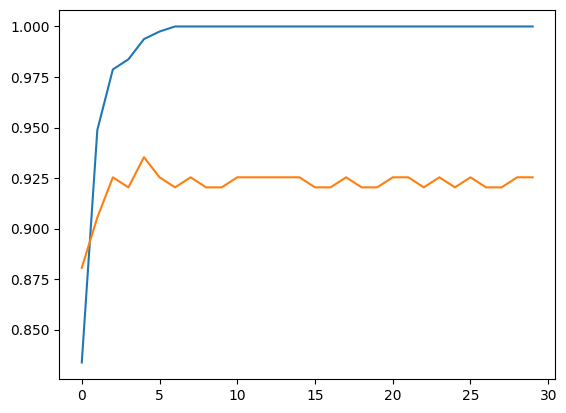

In [89]:
hist = scores[0.0]
plt.plot(hist["accuracy"], label=dr)
plt.plot(hist["val_accuracy"], label=dr)

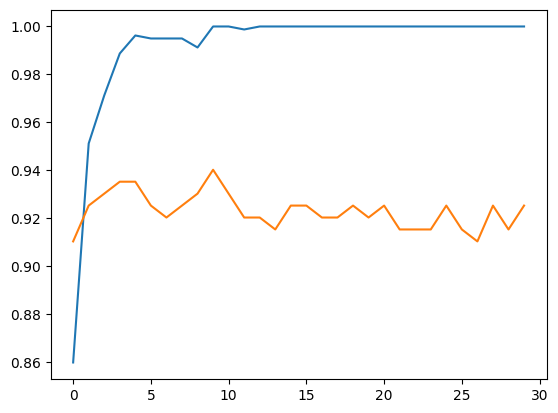

In [90]:
hist = scores[0.2]
plt.plot(hist["accuracy"], label=dr)
plt.plot(hist["val_accuracy"], label=dr)

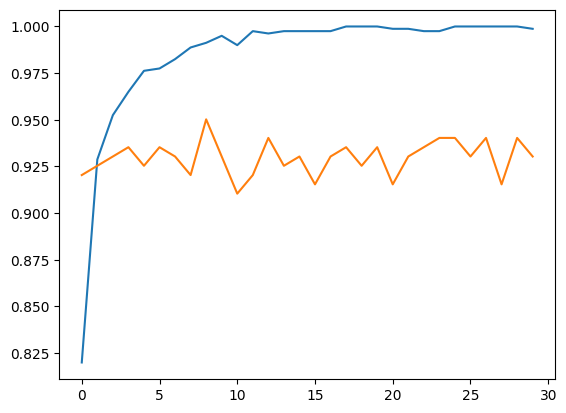

In [91]:
hist = scores[0.5]
plt.plot(hist["accuracy"], label=dr)
plt.plot(hist["val_accuracy"], label=dr)

In [92]:
dr = 0.5

## Data Augmentation

#### Apply transformations to generate more examples (images for this case)

What kind of data do i expect to see (as in dataset)

What kind of variations are in the dataset

Tune as hyperparameter, is it better or not after using certain augmentation?

In [93]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    "../data/train/", 
    target_size=(150, 150), 
    batch_size=32
)

# do not apply to validation set to have consistent results
# compare this model with previous models
val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    "../data/test/", 
    target_size=(150, 150), 
    batch_size=32,
    shuffle=False
)

Found 800 images belonging to 2 classes.
Found 201 images belonging to 2 classes.


In [94]:
print(selected_lr)
print(sz)
print(dr)

0.001
1000
0.5


In [95]:
model_aug = make_model(
    learning_rate=selected_lr,
    size_inner=100,
    droprate=dr
)

history = model_aug.fit(train_ds, epochs=50, validation_data=val_ds)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.5224 - loss: 1.6446 - val_accuracy: 0.5771 - val_loss: 0.6101
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 377ms/step - accuracy: 0.6866 - loss: 0.5708 - val_accuracy: 0.8806 - val_loss: 0.4607
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 402ms/step - accuracy: 0.8657 - loss: 0.4562 - val_accuracy: 0.8905 - val_loss: 0.3650
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 382ms/step - accuracy: 0.8607 - loss: 0.3811 - val_accuracy: 0.8905 - val_loss: 0.2931
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 396ms/step - accuracy: 0.8607 - loss: 0.3214 - val_accuracy: 0.9005 - val_loss: 0.2741
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 394ms/step - accuracy: 0.8657 - loss: 0.2966 - val_accuracy: 0.9204 - val_loss: 0.2220
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 392ms/step - accuracy: 0.9204 - loss: 0.2377 - val_accuracy: 0.9353 - val_loss: 0.1884
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 404ms/step - accuracy: 0.9204 - loss: 0.2180 - val_accuracy: 0.9353 - val_loss: 0

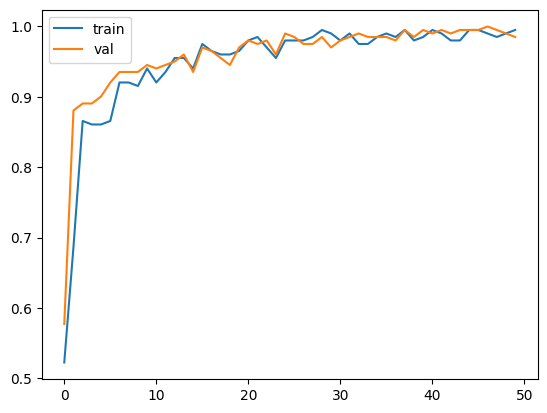

In [96]:
hist = history.history
plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.legend()
plt.show()

## Train a larger model

#### Train using 299x299 images

In [97]:
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    vertical_flip=True
)

train_ds = train_gen.flow_from_directory(
    "../data/train/",
    target_size=(299, 299),
    batch_size=32
)

# do not apply to validation set to have consistent results
# compare this model with previous models
val_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    shear_range=10.0,
    zoom_range=0.1,
    vertical_flip=True
)

val_ds = val_gen.flow_from_directory(
    "../data/test/", 
    target_size=(299, 299), 
    batch_size=32,
    shuffle=False
)

Found 800 images belonging to 2 classes.
Found 201 images belonging to 2 classes.


In [98]:
#copy code from dropout
#size_inner has been set to 100 so it does not take long
def make_model(in_size=299, learning_rate=0.001, size_inner=1000, droprate=0.5):
    base_model = Xception(
        weights="imagenet", 
        include_top=False, 
        input_shape=(in_size, in_size, 3)
    )
    base_model.trainable = False

    inputs = keras.Input(shape=(in_size, in_size, 3))
    base = base_model(inputs, training=False)
    vectors = GlobalAveragePooling2D()(base)
    
    inner_layer = Dense(size_inner, activation="relu")(vectors)
    drop = Dropout(rate=droprate)(inner_layer)

    outputs = Dense(2)(drop)
    #outputs = Dense(2, activation="softmax")(inner_layer)
    model = keras.Model(inputs, outputs)

    optimizer = Adam(learning_rate=learning_rate)
    #no softmax explicitly used as from_logits is True
    loss = CategoricalCrossentropy(from_logits=True)
    
    model.compile(
        optimizer=optimizer, 
        loss=loss, 
        metrics=["accuracy"]
    )

    return model

In [99]:
checkpoint = ModelCheckpoint(
    "xception_lrg_{epoch:02d}_val{val_accuracy:.3f}.keras",
    save_best_only=True,
    monitor="val_accuracy",
    mode="max"
)

In [100]:
model_large = make_model(
    in_size=299,
    learning_rate=0.001,
    size_inner=1000,
    droprate=0.5
)

history = model_large.fit(train_ds, epochs=50, validation_data=val_ds, callbacks=[checkpoint])

Epoch 1/50


2025-11-28 13:36:41.211045: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_4132', 12 bytes spill stores, 12 bytes spill loads

2025-11-28 13:36:47.083748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:36:47.276117: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:36:48.785791: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:36:48.950180: E external/local_xla/xla/st

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.7800 - loss: 0.3908

2025-11-28 13:37:28.704463: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:37:28.837984: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:37:29.485326: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:37:29.613448: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2025-11-28 13:37:30.052986: E external/local_xla/xla/stream_

25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.8637 - loss: 0.2703 - val_accuracy: 0.9652 - val_loss: 0.1016
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step - accuracy: 0.9513 - loss: 0.1154 - val_accuracy: 0.9900 - val_loss: 0.0585
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9625 - loss: 0.1025 - val_accuracy: 0.9652 - val_loss: 0.0782
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9575 - loss: 0.1008 - val_accuracy: 0.9801 - val_loss: 0.0709
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9550 - loss: 0.1044 - val_accuracy: 0.9652 - val_loss: 0.0839
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9725 - loss: 0.0873 - val_accuracy: 0.9751 - val_loss: 0.0903
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9775 - loss: 0.0553 - val_accuracy: 0.9751 - val_loss: 0.0666
Epoch 8/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.9625 - loss: 0.0851 - val_accuracy: 0.9602 - val_loss: 0.0728
Epo

## Using the model

Load, Evaluate, get predictions

In [101]:
# get data
test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_ds = test_gen.flow_from_directory(
    "../data/test/", 
    target_size=(299, 299), 
    batch_size=32,
    shuffle=False
)

Found 201 images belonging to 2 classes.


In [114]:
#load, name of the model has to be updated with desired choice
model_load = load_model("xception_lrg_02_val0.990.keras")

In [115]:
# evaluate
loss, acc = model_load.evaluate(test_ds)
print(f"loss: {loss}, acc:{acc}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 583ms/step - accuracy: 0.9851 - loss: 0.0647
loss: 0.06470496952533722, acc:0.9850746393203735


In [116]:
img = "../data/test/curly/03312ac556a7d003f7570657f80392c34.jpg"

In [117]:
#load_img(img)

In [118]:
img = load_img(img, target_size=(299,299))
x = np.array(img)
X = np.array([x])
X = preprocess_input(X)

In [119]:
preds = model_load.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


In [120]:
class_idxs = train_ds.class_indices
class_idxs

{'curly': 0, 'straight': 1}

In [121]:
class_idxs = train_ds.class_indices
type(class_idxs)

dict

In [122]:
class_idxs = list(class_idxs)
class_idxs

['curly', 'straight']

In [123]:
class_probs = dict(zip(class_idxs, preds[0]))
class_probs

{'curly': np.float32(0.52318186), 'straight': np.float32(-0.93676347)}

In [124]:
prob_class = max(class_probs, key=class_probs.get)
print(f"Probable class: {prob_class} with probability: {class_probs.get(prob_class)}")

Probable class: curly with probability: 0.5231818556785583
